In [1]:
pip install cartopy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import math
# from google.colab import files
# from google.colab import files as colab_files
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import pandas as pd
import cartopy
import xarray as xr
import os

In [3]:
pip install cftime

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


<xarray.Dataset> Size: 67MB
Dimensions:  (time: 365, lat: 163, lon: 283)
Coordinates:
  * time     (time) float64 3kB 1.772e+07 1.772e+07 ... 1.772e+07 1.772e+07
  * lat      (lat) float64 1kB 14.75 15.0 15.25 15.5 ... 54.5 54.75 55.0 55.25
  * lon      (lon) float64 2kB 69.75 70.0 70.25 70.5 ... 139.5 139.8 140.0 140.2
Data variables:
    tm       (time, lat, lon) float32 67MB ...


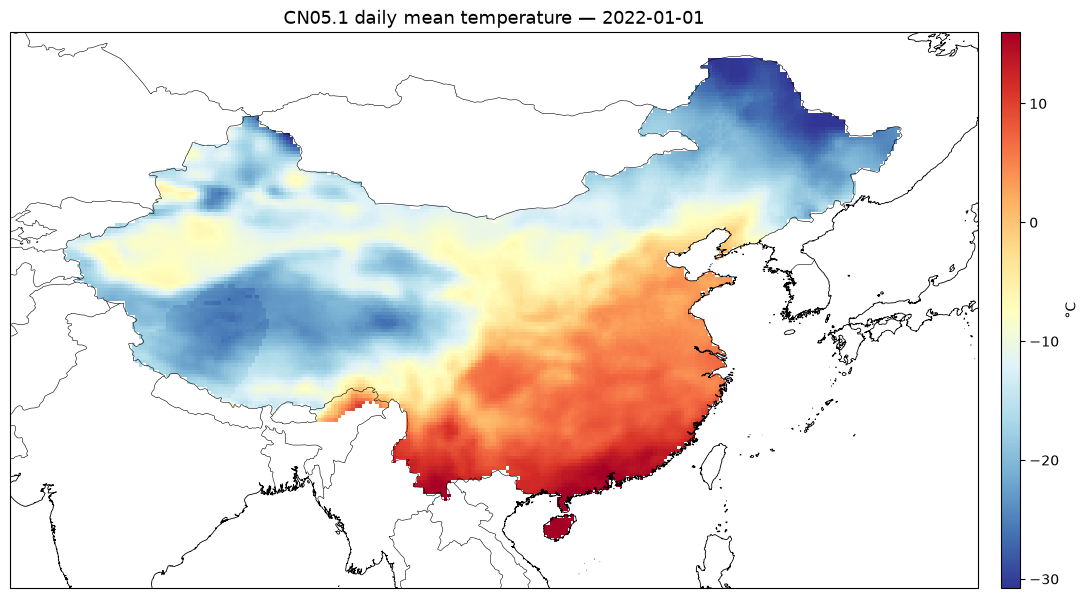

In [8]:
# Plot the 2022-01-01 mean temperature data from the CN05 data as an exmaple

# Colab: Cartopy-only plotting for CN05.1 (time decode workaround)
# Paste entire cell into Colab and run.

# (If you haven't installed cartopy in this runtime, run these once - may take a few minutes)
# !apt-get -qq install -y libproj-dev proj-data proj-bin libgeos-dev
# !pip install -q cartopy

# # 1) Mount Google Drive
# from google.colab import drive
# drive.mount('/content/gdrive')

# 2) Imports
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os


xr.set_options(use_flox=False)


base_dir = "/home/users/weijia_6/Yangtze_code/demand_data"

daily_files = [
    "CN05.1_Tm_1961_2018_daily_025x025.nc",
    "CN05.1_Tm_2019_daily_025x025.nc",
    "CN05.1_Tm_2020_daily_025x025.nc",
    "CN05.1_Tm_2021_daily_025x025.nc",
    "CN05.1_Tm_2022_daily_025x025.nc"
]
daily_paths = [os.path.join(base_dir, f) for f in daily_files]

# province_shp = os.path.join(base_dir, "china_shapefiles", "china.shp")
province_shp = "/home/users/weijia_6/Yangtze_code/geoBoundaries-CHN-ADM1-all/geoBoundaries-CHN-ADM1.shp"
# basins_shp = os.path.join(base_dir, "yangtze", "liuyu.shp")
basins_shp = "/home/users/weijia_6/Yangtze_code/liuyu/liuyu.shp"

# out_png = os.path.join(base_dir, "combined_temp_CDD_insets.png")
out_png = "/home/users/weijia_6/Yangtze_code/demand_result/combined_temp_CDD_insets.png"



# 3) File path
nc_path = "/home/users/weijia_6/Yangtze_code/demand_data/CN05.1_Tm_2022_daily_025x025.nc"
assert os.path.exists(nc_path), f"NetCDF file not found: {nc_path}"

# 4) Open dataset WITHOUT decoding times (avoids cftime / pandas overflow)
ds = xr.open_dataset(nc_path, decode_times=False, mask_and_scale=False)
print(ds)   # quick inspect

# 5) Variable & coords (per your metadata)
var_name = "tm"
time_dim = "time"
lat_name = "lat"
lon_name = "lon"
da = ds[var_name]

# 6) Replace missing / _FillValue with NaN
fill = da.attrs.get("_FillValue", da.attrs.get("missing_value", None))
if fill is not None:
    da = da.where(da != fill, other=np.nan)

# 7) Create a proper datetime index for 2022 and assign to dataset
#    (file contains 365 time steps for 2022 daily data)
n_time = ds.dims[time_dim]
if n_time == 365:
    # build 2022 daily dates (non-leap year)
    dates_2022 = pd.date_range("2022-01-01", periods=365, freq="D")
    # assign to DataArray / Dataset (replace the numeric time coordinate)
    da = da.assign_coords({time_dim: ("time", dates_2022)})
else:
    # fallback: if time length not 365, try to infer from existing numeric times
    try:
        numeric_times = ds[time_dim].values
        # convert numeric times to pandas timedelta (assume units are hours) and add to a safe anchor
        # but avoid using year 0001 to prevent overflow; so instead only build a readable index if possible.
        # Here, just set a generic index starting at 1 (not ideal) — better to inspect ds manually.
        dates = pd.date_range("2001-01-01", periods=n_time, freq="D")
        da = da.assign_coords({time_dim: ("time", dates)})
        print("Note: time length != 365; assigned a generic 2001 date index. Inspect ds.time manually if incorrect.")
    except Exception as e:
        raise RuntimeError("Unable to construct time coordinate automatically. Please inspect dataset time info.") from e

# 8) Select day to plot (by index or by date)
time_index = 0            # 0 = first day (2022-01-01)
# Or select by date string, e.g.:
# date_to_plot = "2022-06-01"
# da_sel = da.sel(time=date_to_plot)
da_sel = da.isel({time_dim: time_index})

# 9) Prepare lon/lat arrays and reorder lon if needed (0..360 -> -180..180)
lon = ds[lon_name].values
lat = ds[lat_name].values

if lon.max() > 180:
    lon = (lon + 180) % 360 - 180
    order = np.argsort(lon)
    lon = lon[order]
    # reorder last dimension (lon) of da_sel — assumes dims order (..., lon)
    # find position of lon dim
    lon_dim = [d for d in da_sel.dims if d.lower().startswith("lon")][0]
    da_sel = da_sel.isel({lon_dim: order})

# 10) Colour scale (robust percentiles)
vmin = float(np.nanpercentile(da_sel.values, 2))
vmax = float(np.nanpercentile(da_sel.values, 98))
pad = 0.05 * (vmax - vmin)
vmin -= pad; vmax += pad

# 11) Plot with Cartopy (PlateCarree)
fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh expects lon, lat 1D arrays and da_sel 2D matching (lat x lon)
# ensure da_sel shape matches (lat, lon)
# If dims are (lat, lon) or (y, x) this will work directly
im = ax.pcolormesh(lon, lat, da_sel.values, transform=ccrs.PlateCarree(),
                   shading='auto', cmap='RdYlBu_r', vmin=vmin, vmax=vmax)

ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

# Title with date
t0 = da.coords[time_dim].values[time_index]
try:
    t0_str = np.datetime_as_string(np.datetime64(t0), unit='D')
except Exception:
    t0_str = str(t0)
ax.set_title(f"CN05.1 daily mean temperature — {t0_str}", fontsize=13)

cb = plt.colorbar(im, pad=0.02, aspect=30)
cb.set_label(da.attrs.get("units", "°C"))

plt.tight_layout()

# # 12) Save figure to your Drive
# out_png = "/content/gdrive/MyDrive/cssp_china/CN05.1_Tm_2022_day_cartopy.png"
# plt.savefig(out_png, dpi=200)
# print("Saved figure to:", out_png)

# plt.savefig("/home/users/weijia_6/Yangtze_code/demand_result/CN05_Tm_2022_day_0_cartopy.png", dpi=300, bbox_inches='tight')
# files.download("CN05_Tm_2022_day_0_cartopy.png")

plt.show()


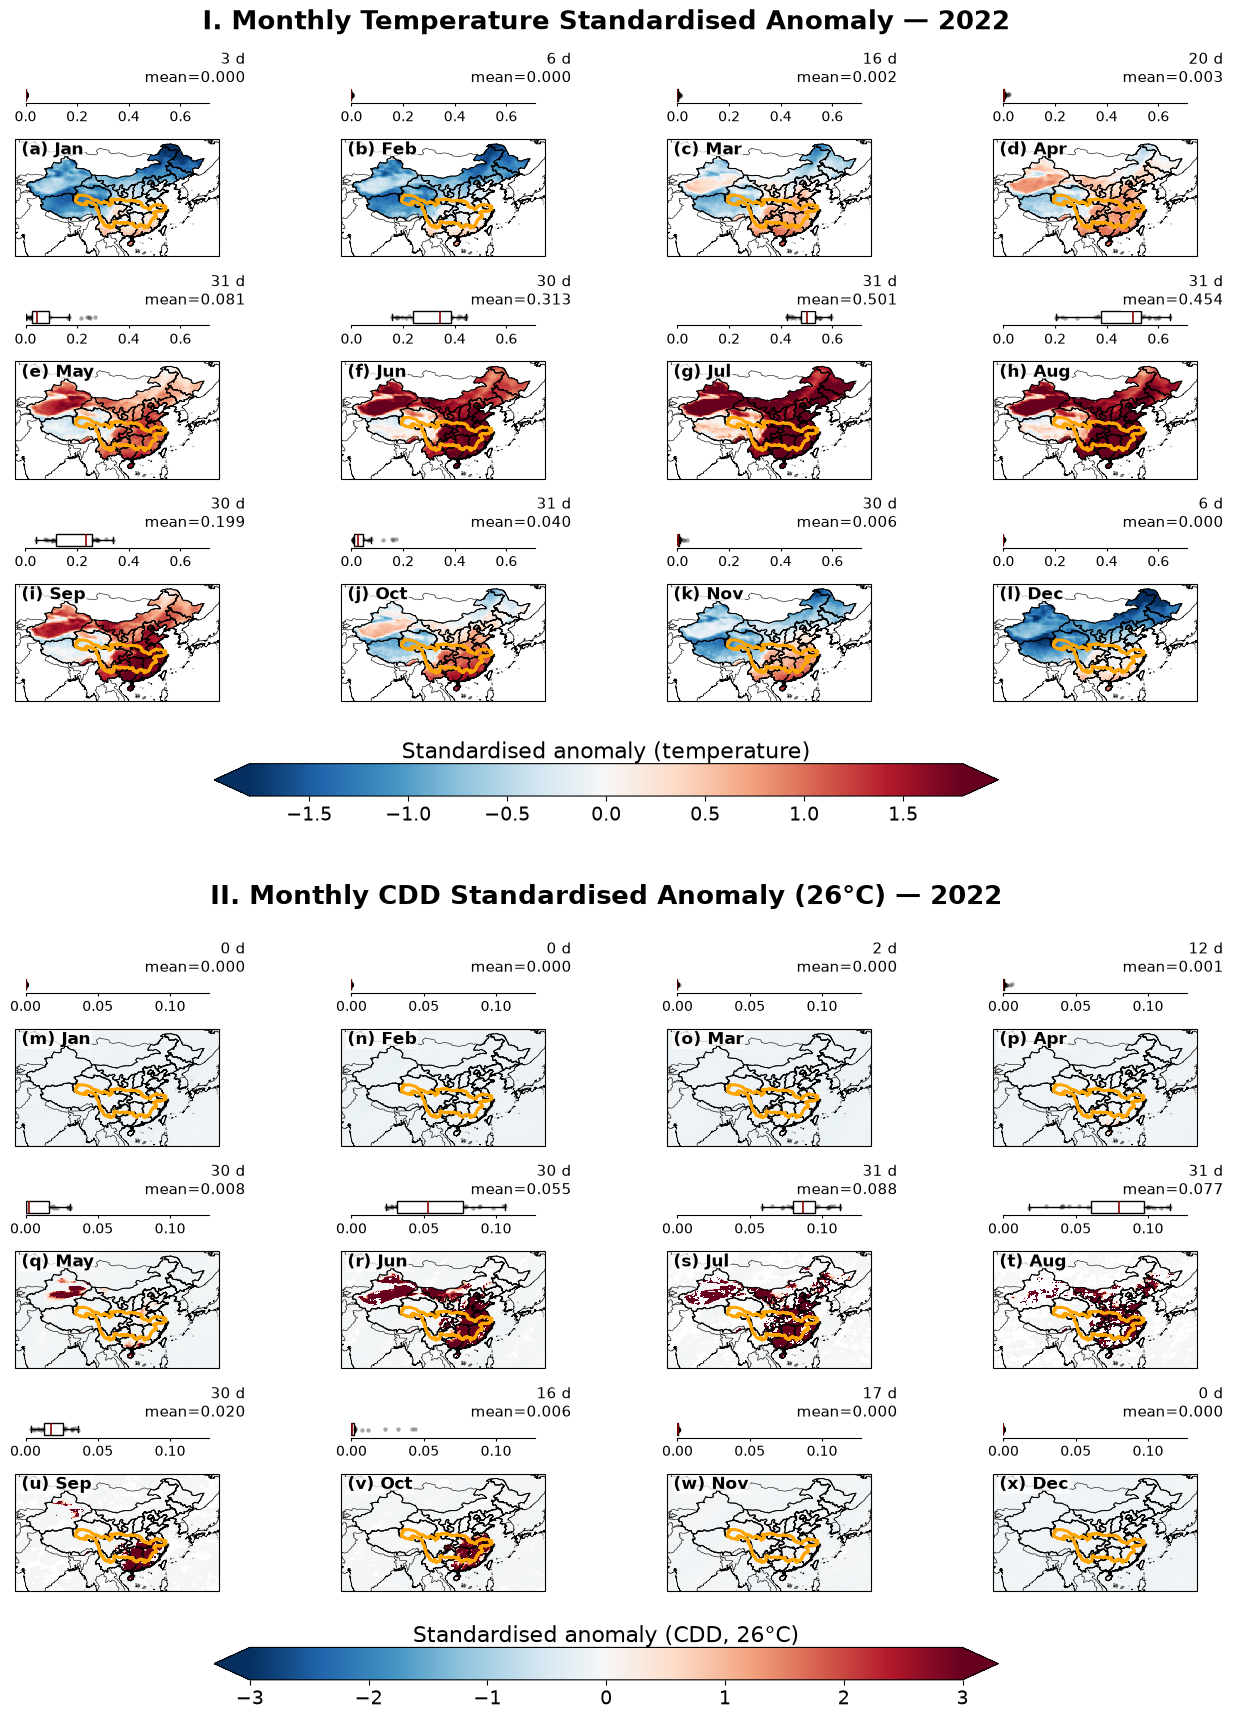

In [16]:
# RAM saving correct all months 2022 China
import os
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
xr.set_options(use_flox=False)
import matplotlib.pyplot as plt
import matplotlib as mpl

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import geopandas as gpd
from shapely.geometry import box

warnings.filterwarnings("ignore")

# ============================================================
# 1. USER PATHS
# ============================================================

base_dir = "/home/users/weijia_6/Yangtze_code/demand_data"

daily_files = [
    "CN05.1_Tm_1961_2018_daily_025x025.nc",
    "CN05.1_Tm_2019_daily_025x025.nc",
    "CN05.1_Tm_2020_daily_025x025.nc",
    "CN05.1_Tm_2021_daily_025x025.nc",
    "CN05.1_Tm_2022_daily_025x025.nc",
]
daily_paths = [os.path.join(base_dir, f) for f in daily_files]

province_shp = os.path.join(base_dir, "china_shapefiles", "china.shp")
basins_shp = "/home/users/weijia_6/Yangtze_code/liuyu/liuyu.shp"

# out_png = os.path.join(base_dir, "combined_temp_CDD_insets.png")
out_png = "/home/users/weijia_6/Yangtze_code/demand_result/combined_temp_CDD_all.png"
OUT_FIG = out_png

os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)

# ============================================================
# 2. LOAD SHAPEFILES
# ============================================================

prov_gdf = gpd.read_file(province_shp).to_crs(epsg=4326)
# basins_gdf = gpd.read_file(basins_shp)

# str_cols = [c for c in basins_gdf.columns if basins_gdf[c].dtype == object]
# yangtze = None
# for c in str_cols:
#     mask = basins_gdf[c].astype(str).str.lower().str.contains("yangt|chang", na=False)
#     if mask.any():
#         yangtze = basins_gdf.loc[mask].to_crs(epsg=4326)
#         break

basins_gdf = gpd.read_file(basins_shp).to_crs(epsg=4326)

# Use the whole shapefile as the Yangtze basin geometry.
# If the file has multiple parts, dissolve them into one boundary.
yangtze = basins_gdf.dissolve()

# ============================================================
# 3. MEMORY-SAFE LOADER
#    - load only the temperature variable
#    - build a clean daily time axis
#    - chunk the array so xarray can work lazily
# ============================================================

def infer_start_date_from_filename(path):
    name = os.path.basename(path)

    if "1961_2018" in name:
        return pd.Timestamp("1961-01-01")
    if "2019" in name:
        return pd.Timestamp("2019-01-01")
    if "2020" in name:
        return pd.Timestamp("2020-01-01")
    if "2021" in name:
        return pd.Timestamp("2021-01-01")
    if "2022" in name:
        return pd.Timestamp("2022-01-01")

    m = re.search(r"_(\d{4})", name)
    if m:
        return pd.Timestamp(f"{m.group(1)}-01-01")

    raise ValueError(f"Cannot infer start date from filename: {name}")


def detect_temp_var(ds):
    candidates = [v for v in ds.data_vars if "tm" in v.lower()]
    if len(candidates) == 0:
        raise ValueError("No temperature variable found.")
    return candidates[0]


def add_clean_time_and_chunk(da, start_date):
    nt = da.sizes["time"]
    clean_time = pd.date_range(start=start_date, periods=nt, freq="D")
    da = da.assign_coords(time=("time", clean_time.to_numpy(dtype="datetime64[ns]")))

    chunk_map = {"time": min(365, nt)}
    for dim in da.dims:
        if dim != "time":
            try:
                dim_size = da.sizes[dim]
                if dim_size > 1:
                    chunk_map[dim] = min(128, dim_size)
            except Exception:
                pass

    try:
        da = da.chunk(chunk_map)
    except Exception:
        pass

    return da


def load_temperature_only(paths):
    pieces = []
    temp_var = None

    for f in paths:
        ds = xr.open_dataset(f, decode_times=False)

        if temp_var is None:
            temp_var = detect_temp_var(ds)
        elif temp_var not in ds.data_vars:
            temp_var = detect_temp_var(ds)

        da = ds[temp_var]

        if "time" not in da.dims:
            raise ValueError(f"'time' dimension not found in file: {f}")

        start_date = infer_start_date_from_filename(f)
        da = add_clean_time_and_chunk(da, start_date)

        pieces.append(da)

    da_daily = xr.concat(pieces, dim="time").sortby("time")

    # Drop duplicate timestamps if any
    time_index = pd.DatetimeIndex(da_daily["time"].values)
    if not time_index.is_unique:
        da_daily = da_daily.isel(time=~time_index.duplicated(keep="first")).sortby("time")

    time_index = pd.DatetimeIndex(da_daily["time"].values)
    if (not time_index.is_monotonic_increasing) or (not time_index.is_unique):
        raise ValueError("Time index is still not strictly increasing after cleaning.")

    # Reduce footprint
    if da_daily.dtype == np.float64:
        da_daily = da_daily.astype(np.float32)

    return da_daily


da_daily = load_temperature_only(daily_paths)

# ============================================================
# 4. PERIODS
# ============================================================

da_baseline = da_daily.sel(time=slice("1961-01-01", "2013-12-31"))
da_2022 = da_daily.sel(time=slice("2022-01-01", "2022-12-31"))

# ============================================================
# 5. CDD FUNCTION
# ============================================================

def compute_CDD(da, threshold=26):
    return xr.where(da > threshold, da - threshold, 0)

# Only compute CDD for the slices we actually use
CDD_baseline = compute_CDD(da_baseline)
CDD_2022 = compute_CDD(da_2022)

# ============================================================
# 6. MONTHLY STANDARDISED ANOMALIES
# ============================================================

temp_clim = da_baseline.groupby("time.month").mean(dim="time")
temp_std = da_baseline.groupby("time.month").std(dim="time")
temp_2022_monthly = da_2022.groupby("time.month").mean(dim="time")
z_temp_2022 = (temp_2022_monthly - temp_clim) / temp_std

cdd_clim = CDD_baseline.groupby("time.month").mean(dim="time")
cdd_std = CDD_baseline.groupby("time.month").std(dim="time")
cdd_2022_monthly = CDD_2022.groupby("time.month").mean(dim="time")
z_cdd_2022 = (cdd_2022_monthly - cdd_clim) / cdd_std

# ============================================================
# 7. RECORD-BREAKING ACTIVITY (TEMP)
# ============================================================

temp_baseline_max = da_baseline.groupby("time.dayofyear").max(dim="time")
temp_doy_2022 = da_2022["time"].dt.dayofyear
temp_baseline_max_2022 = temp_baseline_max.sel(dayofyear=temp_doy_2022)

record_mask_temp = da_2022 > temp_baseline_max_2022

valid_temp_cells = da_2022.isel(time=0).notnull()
n_valid_temp = valid_temp_cells.sum(dim=["lat", "lon"])

daily_record_frac_temp = record_mask_temp.sum(dim=["lat", "lon"]) / n_valid_temp

monthly_record_dist_temp = {
    m: daily_record_frac_temp.where(daily_record_frac_temp["time"].dt.month == m, drop=True).values
    for m in range(1, 13)
}

days_with_any_record_temp = (
    record_mask_temp.any(dim=["lat", "lon"])
    .groupby("time.month")
    .sum()
    .to_pandas()
)

# ============================================================
# 8. RECORD-BREAKING ACTIVITY (CDD)
# ============================================================

cdd_baseline_max = CDD_baseline.groupby("time.dayofyear").max(dim="time")
cdd_doy_2022 = CDD_2022["time"].dt.dayofyear
cdd_baseline_max_2022 = cdd_baseline_max.sel(dayofyear=cdd_doy_2022)

record_mask_cdd = CDD_2022 > cdd_baseline_max_2022

valid_cdd_cells = CDD_2022.isel(time=0).notnull()
n_valid_cdd = valid_cdd_cells.sum(dim=["lat", "lon"])

daily_record_frac_cdd = record_mask_cdd.sum(dim=["lat", "lon"]) / n_valid_cdd

monthly_record_dist_cdd = {
    m: daily_record_frac_cdd.where(daily_record_frac_cdd["time"].dt.month == m, drop=True).values
    for m in range(1, 13)
}

days_with_any_record_cdd = (
    record_mask_cdd.any(dim=["lat", "lon"])
    .groupby("time.month")
    .sum()
    .to_pandas()
)

# ============================================================
# 9. FIGURE SETUP
# ============================================================

fig = plt.figure(figsize=(14, 18)) # fig = plt.figure(figsize=(14, 16))

gs = fig.add_gridspec(
    8, 4,
    left=0.035, right=0.965,
    top=0.965, bottom=0.035,
    hspace=0.9, wspace=0.006     # hspace=0.69, wspace=0.006
)

letters = list("abcdefghijklmnopqrstuvwx")
cmap = "RdBu_r"

norm_temp = mpl.colors.Normalize(vmin=-1.8, vmax=1.8)
norm_cdd = mpl.colors.Normalize(vmin=-3, vmax=3)

lats = da_daily["lat"].values
lons = da_daily["lon"].values
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

rng = np.random.default_rng(42)

def safe_global_xmax(monthly_record_dist):
    vals_all = []
    for m in range(1, 13):
        vals = np.asarray(monthly_record_dist[m])
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            vals_all.append(vals)
    if len(vals_all) == 0:
        return 0.01
    return max(np.nanmax(np.concatenate(vals_all)) * 1.10, 0.01)

global_xmax_temp = safe_global_xmax(monthly_record_dist_temp)
global_xmax_cdd = safe_global_xmax(monthly_record_dist_cdd)

# ============================================================
# 10. OVERLAY HELPER
# ============================================================

def draw_overlays(ax):
    bbox_geom = box(extent[0], extent[2], extent[1], extent[3])
    subset = prov_gdf[prov_gdf.geometry.intersects(bbox_geom)]

    for geom in subset.geometry:
        ax.add_geometries(
            [geom],
            crs=ccrs.PlateCarree(),
            facecolor="none",
            edgecolor="black",
            linewidth=0.7,
            zorder=4#4
        )

    if yangtze is not None:
        for geom in yangtze.geometry:
            ax.add_geometries(
                [geom],
                crs=ccrs.PlateCarree(),
                facecolor="none",
                edgecolor="orange", # darkorange
                linewidth=2.0,
                zorder=8#6
            )


    ax.coastlines(resolution="10m", linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

# ============================================================
# 11. FLOATING INSET HELPER
# ============================================================

def add_record_inset(ax, month, monthly_record_dist, days_with_any_record, global_xmax, fig):
    vals = np.asarray(monthly_record_dist[month])
    vals = vals[np.isfinite(vals)]

    bbox = ax.get_position()

    inset = fig.add_axes([
        bbox.x0 + 0.05 * bbox.width,
        bbox.y1 + 0.020,
        0.90 * bbox.width,
        0.14 * bbox.height
    ])

    inset.set_facecolor((1, 1, 1, 0.94))

    if len(vals) > 0:
        inset.boxplot(
            vals,
            vert=False,
            widths=0.72,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.0),
            medianprops=dict(color="darkred", linewidth=1.2),
            whiskerprops=dict(color="black", linewidth=1.0),
            capprops=dict(color="black", linewidth=1.0),
        )

        y_jitter = 1 + (rng.random(len(vals)) - 0.5) * 0.12
        inset.scatter(
            vals,
            y_jitter,
            s=10,
            alpha=0.35,
            color="black",
            linewidths=0
        )

        inset.set_xlim(0, global_xmax)

        days_any = int(days_with_any_record.loc[month]) if month in days_with_any_record.index else 0
        mean_frac = float(np.nanmean(vals))

        inset.text(
            1.2, 3.2, # 0.98, 2.5,
            f"{days_any} d\nmean={mean_frac:.3f}",
            transform=inset.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(facecolor="white", alpha=0.82, pad=0.8, edgecolor="none")
        )
    else:
        inset.text(
            0.5, 0.5,
            "No data",
            ha="center",
            va="center",
            fontsize=11
        )

    inset.set_yticks([])
    inset.tick_params(axis="x", labelsize=10, length=2)
    inset.tick_params(axis="y", left=False, labelleft=False)

    for spine in ["top", "right", "left"]:
        inset.spines[spine].set_visible(False)

    return inset

# ============================================================
# 12. PANEL PLOTTING FUNCTION
# ============================================================

def plot_panel(
    z_da,
    row_offset,
    title,
    norm,
    monthly_record_dist,
    days_with_any_record,
    global_xmax,
    title_y
):
    for m in range(1, 13):
        r = row_offset + (m - 1) // 4
        c = (m - 1) % 4

        ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())

        data = z_da.sel(month=m).values

        ax.pcolormesh(
            lons, lats, data,
            cmap=cmap,
            norm=norm,
            transform=ccrs.PlateCarree(),
            shading="auto"
        )

        draw_overlays(ax)

        month_label = pd.to_datetime(f"2022-{m:02d}-01").strftime("%b")

        letter_offset = 0 if row_offset == 0 else 12
        panel_label = letters[letter_offset + (m - 1)]

        ax.text(
            0.03, 0.98,
            f"({panel_label}) {month_label}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=12,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.72, pad=1.0, edgecolor="none")
        )

        add_record_inset(
            ax=ax,
            month=m,
            monthly_record_dist=monthly_record_dist,
            days_with_any_record=days_with_any_record,
            global_xmax=global_xmax,
            fig=fig
        )

    fig.text(0.5, title_y, title, ha="center", fontsize=19, weight="bold")

# ============================================================
# 13. DRAW BOTH PANELS
# ============================================================

plot_panel(
    z_temp_2022,
    row_offset=0,
    title="I. Monthly Temperature Standardised Anomaly — 2022",
    norm=norm_temp,
    monthly_record_dist=monthly_record_dist_temp,
    days_with_any_record=days_with_any_record_temp,
    global_xmax=global_xmax_temp,
    title_y=1.026
)

plot_panel(
    z_cdd_2022,
    row_offset=4,
    title="II. Monthly CDD Standardised Anomaly (26°C) — 2022",
    norm=norm_cdd,
    monthly_record_dist=monthly_record_dist_cdd,
    days_with_any_record=days_with_any_record_cdd,
    global_xmax=global_xmax_cdd,
    title_y=0.54
)

# ============================================================
# 14. COLOURBARS
# ============================================================

cax1 = fig.add_axes([0.22, 0.6, 0.56, 0.018])
sm1 = mpl.cm.ScalarMappable(norm=norm_temp, cmap=cmap)
fig.colorbar(sm1, cax=cax1, orientation="horizontal", extend="both")
cax1.set_title("Standardised anomaly (temperature)", fontsize=16, pad=2)
cax1.tick_params(labelsize=14)

cax2 = fig.add_axes([0.22, 0.109, 0.56, 0.018])
sm2 = mpl.cm.ScalarMappable(norm=norm_cdd, cmap=cmap)
fig.colorbar(sm2, cax=cax2, orientation="horizontal", extend="both")
cax2.set_title("Standardised anomaly (CDD, 26°C)", fontsize=16, pad=2)
cax2.tick_params(labelsize=14)

# ============================================================
# 15. SAVE AND SHOW
# ============================================================

plt.savefig(OUT_FIG, dpi=300, bbox_inches="tight", pad_inches=0.15)
plt.show()
plt.close(fig)

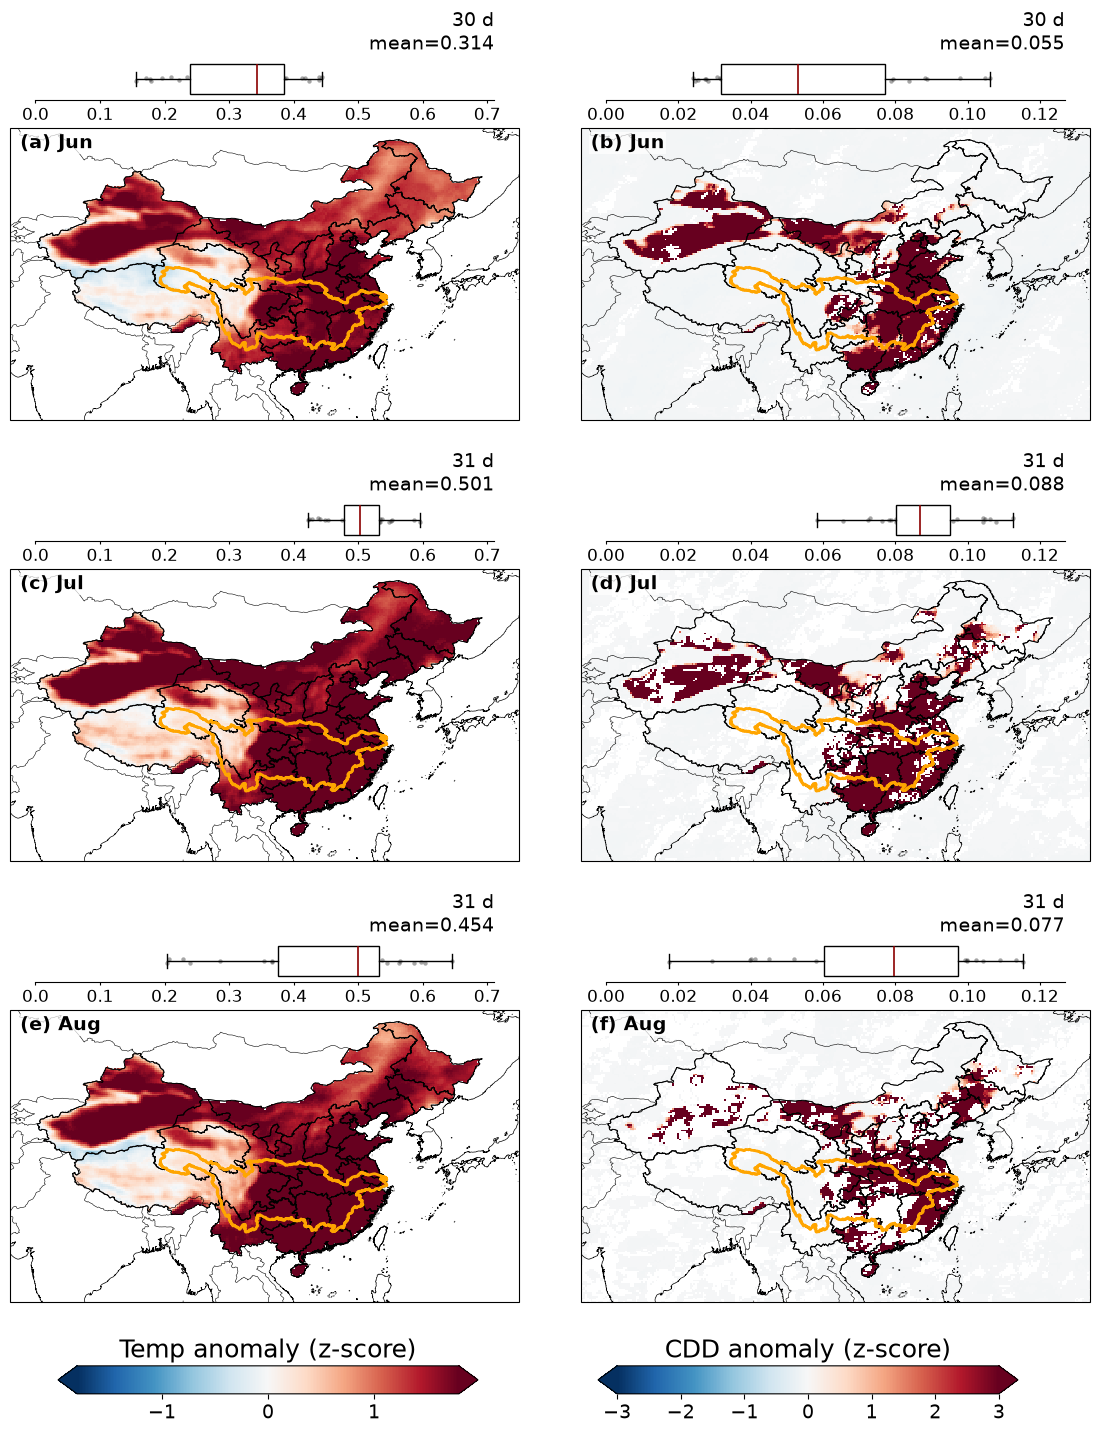

In [14]:
# JJA figure (RAM saving mode)

import os
import re
import warnings

import xarray as xr
xr.set_options(use_flox=False)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import geopandas as gpd
from shapely.geometry import box

warnings.filterwarnings("ignore")

# ============================================================
# 1. USER PATHS
# ============================================================

base_dir = "/home/users/weijia_6/Yangtze_code/demand_data"

daily_files = [
    "CN05.1_Tm_1961_2018_daily_025x025.nc",
    "CN05.1_Tm_2019_daily_025x025.nc",
    "CN05.1_Tm_2020_daily_025x025.nc",
    "CN05.1_Tm_2021_daily_025x025.nc",
    "CN05.1_Tm_2022_daily_025x025.nc",
]
daily_paths = [os.path.join(base_dir, f) for f in daily_files]

province_shp = os.path.join(base_dir, "china_shapefiles", "china.shp")
basins_shp = "/home/users/weijia_6/Yangtze_code/liuyu/liuyu.shp"

out_png = "/home/users/weijia_6/Yangtze_code/demand_result/JJA_temp_CDD_panel.png"
OUT_FIG = out_png

os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)


# ============================================================
# 2. LOAD SHAPEFILES
# ============================================================

prov_gdf = gpd.read_file(province_shp).to_crs(epsg=4326)
# basins_gdf = gpd.read_file(basins_shp)

# str_cols = [c for c in basins_gdf.columns if basins_gdf[c].dtype == object]
# yangtze = None
# for c in str_cols:
#     mask = basins_gdf[c].astype(str).str.lower().str.contains("yangt|chang", na=False)
#     if mask.any():
#         yangtze = basins_gdf.loc[mask].to_crs(epsg=4326)
#         break

basins_gdf = gpd.read_file(basins_shp).to_crs(epsg=4326)

# Use the whole shapefile as the Yangtze basin geometry.
# If the file has multiple parts, dissolve them into one boundary.
yangtze = basins_gdf.dissolve()

# ============================================================
# 3. MEMORY-SAFE LOADER
# ============================================================

def infer_start_date_from_filename(path):
    name = os.path.basename(path)

    if "1961_2018" in name:
        return pd.Timestamp("1961-01-01")
    if "2019" in name:
        return pd.Timestamp("2019-01-01")
    if "2020" in name:
        return pd.Timestamp("2020-01-01")
    if "2021" in name:
        return pd.Timestamp("2021-01-01")
    if "2022" in name:
        return pd.Timestamp("2022-01-01")

    m = re.search(r"_(\d{4})", name)
    if m:
        return pd.Timestamp(f"{m.group(1)}-01-01")

    raise ValueError(f"Cannot infer start date from filename: {name}")


def detect_temp_var(ds):
    candidates = [v for v in ds.data_vars if "tm" in v.lower()]
    if len(candidates) == 0:
        raise ValueError("No temperature variable found.")
    return candidates[0]


def add_clean_time_and_chunk(da, start_date):
    nt = da.sizes["time"]
    clean_time = pd.date_range(start=start_date, periods=nt, freq="D")
    da = da.assign_coords(time=("time", clean_time.to_numpy(dtype="datetime64[ns]")))

    chunk_map = {"time": min(365, nt)}
    for dim in da.dims:
        if dim != "time":
            try:
                dim_size = da.sizes[dim]
                if dim_size > 1:
                    chunk_map[dim] = min(128, dim_size)
            except Exception:
                pass

    try:
        da = da.chunk(chunk_map)
    except Exception:
        pass

    return da


def load_temperature_only(paths):
    pieces = []
    temp_var = None

    for f in paths:
        ds = xr.open_dataset(f, decode_times=False)

        if temp_var is None:
            temp_var = detect_temp_var(ds)
        elif temp_var not in ds.data_vars:
            temp_var = detect_temp_var(ds)

        da = ds[temp_var]

        if "time" not in da.dims:
            raise ValueError(f"'time' dimension not found in file: {f}")

        start_date = infer_start_date_from_filename(f)
        da = add_clean_time_and_chunk(da, start_date)
        pieces.append(da)

    da_daily = xr.concat(pieces, dim="time").sortby("time")

    time_index = pd.DatetimeIndex(da_daily["time"].values)
    if not time_index.is_unique:
        da_daily = da_daily.isel(time=~time_index.duplicated(keep="first")).sortby("time")

    time_index = pd.DatetimeIndex(da_daily["time"].values)
    if (not time_index.is_monotonic_increasing) or (not time_index.is_unique):
        raise ValueError("Time index is still not strictly increasing after cleaning.")

    if da_daily.dtype == np.float64:
        da_daily = da_daily.astype(np.float32)

    return da_daily


da_daily = load_temperature_only(daily_paths)

# ============================================================
# 4. JJA-ONLY PERIODS
# ============================================================

months_jja = [6, 7, 8]

da_baseline = da_daily.sel(time=slice("1961-01-01", "2013-12-31"))
da_2022 = da_daily.sel(time=slice("2022-01-01", "2022-12-31"))

da_baseline_jja = da_baseline.sel(time=da_baseline["time"].dt.month.isin(months_jja))
da_2022_jja = da_2022.sel(time=da_2022["time"].dt.month.isin(months_jja))

# ============================================================
# 5. CDD FUNCTION
# ============================================================

def compute_CDD(da, threshold=26):
    return xr.where(da > threshold, da - threshold, 0)

CDD_baseline_jja = compute_CDD(da_baseline_jja)
CDD_2022_jja = compute_CDD(da_2022_jja)

# ============================================================
# 6. JJA MONTHLY STANDARDISED ANOMALIES
# ============================================================

temp_clim = da_baseline_jja.groupby("time.month").mean(dim="time")
temp_std = da_baseline_jja.groupby("time.month").std(dim="time")
temp_2022_monthly = da_2022_jja.groupby("time.month").mean(dim="time")
z_temp_2022 = (temp_2022_monthly - temp_clim) / temp_std

cdd_clim = CDD_baseline_jja.groupby("time.month").mean(dim="time")
cdd_std = CDD_baseline_jja.groupby("time.month").std(dim="time")
cdd_2022_monthly = CDD_2022_jja.groupby("time.month").mean(dim="time")
z_cdd_2022 = (cdd_2022_monthly - cdd_clim) / cdd_std

# ============================================================
# 7. JJA RECORD-BREAKING ACTIVITY (TEMP)
# ============================================================

temp_baseline_max = da_baseline_jja.groupby("time.dayofyear").max(dim="time")
temp_doy_2022 = da_2022_jja["time"].dt.dayofyear
temp_baseline_max_2022 = temp_baseline_max.sel(dayofyear=temp_doy_2022)

record_mask_temp = da_2022_jja > temp_baseline_max_2022

valid_temp_cells = da_2022_jja.isel(time=0).notnull()
n_valid_temp = valid_temp_cells.sum(dim=["lat", "lon"])

daily_record_frac_temp = record_mask_temp.sum(dim=["lat", "lon"]) / n_valid_temp

monthly_record_dist_temp = {
    m: daily_record_frac_temp.where(daily_record_frac_temp["time"].dt.month == m, drop=True).values
    for m in months_jja
}

days_with_any_record_temp = (
    record_mask_temp.any(dim=["lat", "lon"])
    .groupby("time.month")
    .sum()
    .to_pandas()
)

days_with_any_record_temp = days_with_any_record_temp.loc[months_jja]

# ============================================================
# 8. JJA RECORD-BREAKING ACTIVITY (CDD)
# ============================================================

cdd_baseline_max = CDD_baseline_jja.groupby("time.dayofyear").max(dim="time")
cdd_doy_2022 = CDD_2022_jja["time"].dt.dayofyear
cdd_baseline_max_2022 = cdd_baseline_max.sel(dayofyear=cdd_doy_2022)

record_mask_cdd = CDD_2022_jja > cdd_baseline_max_2022

valid_cdd_cells = CDD_2022_jja.isel(time=0).notnull()
n_valid_cdd = valid_cdd_cells.sum(dim=["lat", "lon"])

daily_record_frac_cdd = record_mask_cdd.sum(dim=["lat", "lon"]) / n_valid_cdd

monthly_record_dist_cdd = {
    m: daily_record_frac_cdd.where(daily_record_frac_cdd["time"].dt.month == m, drop=True).values
    for m in months_jja
}

days_with_any_record_cdd = (
    record_mask_cdd.any(dim=["lat", "lon"])
    .groupby("time.month")
    .sum()
    .to_pandas()
)

days_with_any_record_cdd = days_with_any_record_cdd.loc[months_jja]

# ============================================================
# 9. COMMON VARIABLES
# ============================================================

cmap = "RdBu_r"
norm_temp = mpl.colors.Normalize(vmin=-1.8, vmax=1.8)
norm_cdd = mpl.colors.Normalize(vmin=-3, vmax=3)

lats = da_daily["lat"].values
lons = da_daily["lon"].values
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

rng = np.random.default_rng(42)

def safe_global_xmax(monthly_record_dist):
    vals_all = []
    for m in months_jja:
        vals = np.asarray(monthly_record_dist[m])
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            vals_all.append(vals)
    if len(vals_all) == 0:
        return 0.01
    return max(np.nanmax(np.concatenate(vals_all)) * 1.10, 0.01)

global_xmax_temp = safe_global_xmax(monthly_record_dist_temp)
global_xmax_cdd = safe_global_xmax(monthly_record_dist_cdd)

# ============================================================
# 10. OVERLAY HELPER
# ============================================================

def draw_overlays(ax):
    bbox_geom = box(extent[0], extent[2], extent[1], extent[3])
    subset = prov_gdf[prov_gdf.geometry.intersects(bbox_geom)]

    for geom in subset.geometry:
        ax.add_geometries(
            [geom],
            crs=ccrs.PlateCarree(),
            facecolor="none",
            edgecolor="black",# black
            linewidth=0.7, #0.7
            zorder=4 #4
        )

    if yangtze is not None:
        for geom in yangtze.geometry:
            ax.add_geometries(
                [geom],
                crs=ccrs.PlateCarree(),
                facecolor="none",
                edgecolor="orange", # darkorange
                linewidth=2.0,
                zorder=8 #6
            )

    ax.coastlines(resolution="10m", linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

# ============================================================
# 11. INSET HELPER
# ============================================================

def add_record_inset(ax, month, monthly_record_dist, days_with_any_record, global_xmax, fig):
    vals = np.asarray(monthly_record_dist[month])
    vals = vals[np.isfinite(vals)]

    bbox = ax.get_position()

    inset = fig.add_axes([
        bbox.x0 + 0.05 * bbox.width,
        bbox.y1 + 0.020,
        0.90 * bbox.width,
        0.14 * bbox.height
    ])

    inset.set_facecolor((1, 1, 1, 0.94))

    if len(vals) > 0:
        inset.boxplot(
            vals,
            vert=False,
            widths=0.72,
            showfliers=False,
            patch_artist=True,
            boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.0),
            medianprops=dict(color="darkred", linewidth=1.2),
            whiskerprops=dict(color="black", linewidth=1.0),
            capprops=dict(color="black", linewidth=1.0),
        )

        y_jitter = 1 + (rng.random(len(vals)) - 0.5) * 0.12
        inset.scatter(
            vals,
            y_jitter,
            s=10,
            alpha=0.35,
            color="black",
            linewidths=0
        )

        inset.set_xlim(0, global_xmax)

        days_any = int(days_with_any_record.loc[month]) if month in days_with_any_record.index else 0
        mean_frac = float(np.nanmean(vals))

        inset.text(
            1.0, 2.2, #             1.0, 1.6,
            f"{days_any} d\nmean={mean_frac:.3f}",
            transform=inset.transAxes,
            ha="right",
            va="top",
            fontsize=14,
            bbox=dict(facecolor="white", alpha=0.82, pad=0.8, edgecolor="none")
        )
    else:
        inset.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)

    inset.set_yticks([])
    inset.tick_params(axis="x", labelsize=12, length=2)
    inset.tick_params(axis="y", left=False, labelleft=False)

    for spine in ["top", "right", "left"]:
        inset.spines[spine].set_visible(False)

    return inset

# ============================================================
# 12. JJA PANEL FIGURE
# ============================================================

figJ = plt.figure(figsize=(12, 14))

gsJ = figJ.add_gridspec(
    3, 2,
    left=0.06, right=0.96,
    top=0.94, bottom=0.10,
    hspace=0.5, wspace=0.12 #     hspace=0.32, wspace=0.12
)

month_names = {6: "Jun", 7: "Jul", 8: "Aug"}
letters_JJA = ["a", "b", "c", "d", "e", "f"]

def plot_JJA_panel(ax, month, z_da, norm, monthly_record_dist,
                   days_with_any_record, global_xmax, label):

    data = z_da.sel(month=month).values

    ax.pcolormesh(
        lons, lats, data,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading="auto"
    )

    draw_overlays(ax)

    ax.text(
        0.02, 0.98,
        f"({label}) {month_names[month]}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=14, weight="bold",
        bbox=dict(facecolor="white", alpha=0.72, pad=1.0, edgecolor="none")
    )

    add_record_inset(
        ax=ax,
        month=month,
        monthly_record_dist=monthly_record_dist,
        days_with_any_record=days_with_any_record,
        global_xmax=global_xmax,
        fig=figJ
    )

# Build layout
for i, m in enumerate(months_jja):
    axL = figJ.add_subplot(gsJ[i, 0], projection=ccrs.PlateCarree())
    plot_JJA_panel(
        ax=axL,
        month=m,
        z_da=z_temp_2022,
        norm=norm_temp,
        monthly_record_dist=monthly_record_dist_temp,
        days_with_any_record=days_with_any_record_temp,
        global_xmax=global_xmax_temp,
        label=letters_JJA[2 * i]
    )

    axR = figJ.add_subplot(gsJ[i, 1], projection=ccrs.PlateCarree())
    plot_JJA_panel(
        ax=axR,
        month=m,
        z_da=z_cdd_2022,
        norm=norm_cdd,
        monthly_record_dist=monthly_record_dist_cdd,
        days_with_any_record=days_with_any_record_cdd,
        global_xmax=global_xmax_cdd,
        label=letters_JJA[2 * i + 1]
    )

# figJ.text(0.28, 0.965, "I. JJA Temperature Standardised Anomaly — 2022",
#           ha="center", fontsize=18, weight="bold")
# figJ.text(0.74, 0.965, "II. JJA CDD Standardised Anomaly (26°C) — 2022",
#           ha="center", fontsize=18, weight="bold")

# Colourbars
caxT = figJ.add_axes([0.10, 0.035, 0.35, 0.02])
smT = mpl.cm.ScalarMappable(norm=norm_temp, cmap=cmap)
figJ.colorbar(smT, cax=caxT, orientation="horizontal", extend="both")
caxT.set_title("Temp anomaly (z-score)", fontsize=18)
caxT.tick_params(labelsize=14)

caxC = figJ.add_axes([0.55, 0.035, 0.35, 0.02])
smC = mpl.cm.ScalarMappable(norm=norm_cdd, cmap=cmap)
figJ.colorbar(smC, cax=caxC, orientation="horizontal", extend="both")
caxC.set_title("CDD anomaly (z-score)", fontsize=18)
caxC.tick_params(labelsize=14)

plt.savefig(OUT_FIG, dpi=400, bbox_inches="tight")
plt.show()
plt.close(figJ)

In [13]:
import geopandas as gpd

basins_shp = "/home/users/weijia_6/Yangtze_code/liuyu/liuyu.shp"
gdf = gpd.read_file(basins_shp)

print(gdf.columns)
for c in gdf.columns:
    if gdf[c].dtype == object:
        vals = gdf[c].dropna().astype(str).unique()[:20]
        print("\nColumn:", c)
        print(vals)

Index(['AREA', 'PERIMETER', 'W1102WB000', 'W1102WB0_1', 'W1102WB0_2',
       'geometry'],
      dtype='str')
